In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
import matplotlib.style
import matplotlib as mpl
mpl.style.use('classic')
from mpl_toolkits.mplot3d import Axes3D


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/train.csv
/kaggle/input/train.csv.zip
/kaggle/input/sample_submission.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv
/kaggle/input/test.csv.zip
/kaggle/input/description.md
/kaggle/input/ventilator-pressure-prediction/train.csv
/kaggle/input/ventilator-pressure-prediction/train.csv.zip
/kaggle/input/ventilator-pressure-prediction/sample_submission.csv
/kaggle/input/ventilator-pressure-prediction/sample_submission.csv.zip
/kaggle/input/ventilator-pressure-prediction/test.csv
/kaggle/input/ventilator-pressure-prediction/test.csv.zip
/kaggle/input/ventilator-pressure-prediction/description.md


In [3]:
train = pd.read_csv("/kaggle/input/ventilator-pressure-prediction/train.csv")
test = pd.read_csv("/kaggle/input/ventilator-pressure-prediction/test.csv")
submission = pd.read_csv("/kaggle/input/ventilator-pressure-prediction/sample_submission.csv")


In [4]:
train


,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,85053,5,10,0.000000,4.174419,0,6.118700
1,2,85053,5,10,0.033812,7.050149,0,5.907794
2,3,85053,5,10,0.067497,7.564931,0,7.313837
3,4,85053,5,10,0.101394,8.103306,0,8.227765
4,5,85053,5,10,0.135344,8.502619,0,9.422901
...,...,...,...,...,...,...,...,...
5432395,5432396,113800,50,10,2.586557,4.978365,1,6.751420
5432396,5432397,113800,50,10,2.621924,4.981872,1,6.540513
5432397,5432398,113800,50,10,2.655996,4.984711,1,6.399909
5432398,5432399,113800,50,10,2.690135,4.987111,1,6.681117


In [5]:
test


,id,breath_id,R,C,time_step,u_in,u_out
0,1,44398,50,20,0.000000,0.133805,0
1,2,44398,50,20,0.031955,2.411108,0
2,3,44398,50,20,0.063910,4.484026,0
3,4,44398,50,20,0.095838,9.191747,0
4,5,44398,50,20,0.128655,14.005526,0
...,...,...,...,...,...,...,...
603595,603596,124490,50,20,2.394955,4.943961,1
603596,603597,124490,50,20,2.427024,4.952263,1
603597,603598,124490,50,20,2.458956,4.959308,1
603598,603599,124490,50,20,2.490949,4.965323,1


In [6]:
submission


,id,pressure
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
603595,603596,0
603596,603597,0
603597,603598,0
603598,603599,0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


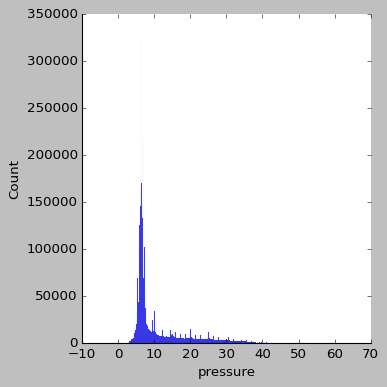

In [7]:
sns.displot(train['pressure'])


In [8]:
target = train['pressure']
print("Minimum value: ", target.min())
print("Maximum value: ", target.max())
print("Average value: ", target.mean())
print("Standard deviation: ", target.std())


Minimum value:  -1.895744295
Maximum value:  64.82099174
Average value:  11.218069409525942
Standard deviation:  8.106473982205056


In [9]:
combi = train.drop(['pressure'], axis=1).append(test)
combi


AttributeError: 'DataFrame' object has no attribute 'append'

In [10]:
combi.drop(['id'],axis=1, inplace=True)
combi


NameError: name 'combi' is not defined

In [11]:
combi.isnull().sum()


NameError: name 'combi' is not defined

In [12]:
#combi = (combi - combi.min()) / (combi.max() - combi.min())
#combi


In [13]:
combi = (combi - combi.mean()) / np.std(combi)
combi


NameError: name 'combi' is not defined

In [14]:
y = target
X = combi[: len(train)]
X_test = combi[len(train) :]

y = np.array(y, dtype=np.float32)
X = np.array(X, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
X.shape, y.shape, X_test.shape


NameError: name 'combi' is not defined

In [15]:
# Visualize our data
import matplotlib.pyplot as plt
import numpy as np

x = X[:,3]
y = y

plt.scatter(x, y)
plt.show()


NameError: name 'X' is not defined

In [16]:
#try:- https://www.analyticsvidhya.com/blog/2020/10/perform-regression-analysis-with-pytorch-seamlessly/
import torch
import torch.nn as nn 


In [17]:
X_tensor = torch.from_numpy(X.reshape(X.shape[0],X.shape[1]))
X_test_tensor = torch.from_numpy(X_test.reshape(X_test.shape[0],X_test.shape[1]))
y_tensor = torch.from_numpy(y.reshape(y.shape[0],1))

X_tensor.shape, y_tensor.shape, X_test_tensor.shape


NameError: name 'X' is not defined

In [18]:
input_size = 6
output_size = 1


In [19]:
model = nn.Linear(input_size , output_size)


In [20]:
learning_rate = 0.0001
l = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr =learning_rate )


In [21]:
num_epochs = 500

for epoch in range(num_epochs):
    #forward feed
    y_pred = model(X_tensor.requires_grad_())

    #calculate the loss
    loss= l(y_pred, y_tensor)

    #backward propagation: calculate gradients
    loss.backward()

    #update the weights
    optimizer.step()

    #clear out the gradients from the last step loss.backward()
    optimizer.zero_grad()
    
    print('epoch {}, loss {}'.format(epoch, loss.item()))


NameError: name 'X_tensor' is not defined

In [22]:
prediction = model(X_tensor).detach().numpy()
prediction


NameError: name 'X_tensor' is not defined

In [23]:
plt.scatter(X_tensor[:,3].detach().numpy()[:100] , y_tensor.detach().numpy()[:100])
plt.plot(X_tensor[:, 3].detach().numpy()[:100] , prediction[:100] , "red")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


NameError: name 'X_tensor' is not defined

In [24]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_tensor.detach().numpy(), prediction, squared=False)
rmse


NameError: name 'y_tensor' is not defined

In [25]:
compare = pd.DataFrame({'actual': y, 'predicted': prediction.ravel()})
compare


NameError: name 'prediction' is not defined

In [26]:
test_prediction = model(X_test_tensor).detach().numpy()
test_prediction[test_prediction < 0] = 0
test_prediction


NameError: name 'X_test_tensor' is not defined

In [27]:
submission['pressure'] = test_prediction
submission.to_csv('submission.csv',index=False) # writing data to a CSV file
submission = pd.read_csv("submission.csv")
submission


NameError: name 'test_prediction' is not defined